HITO 1

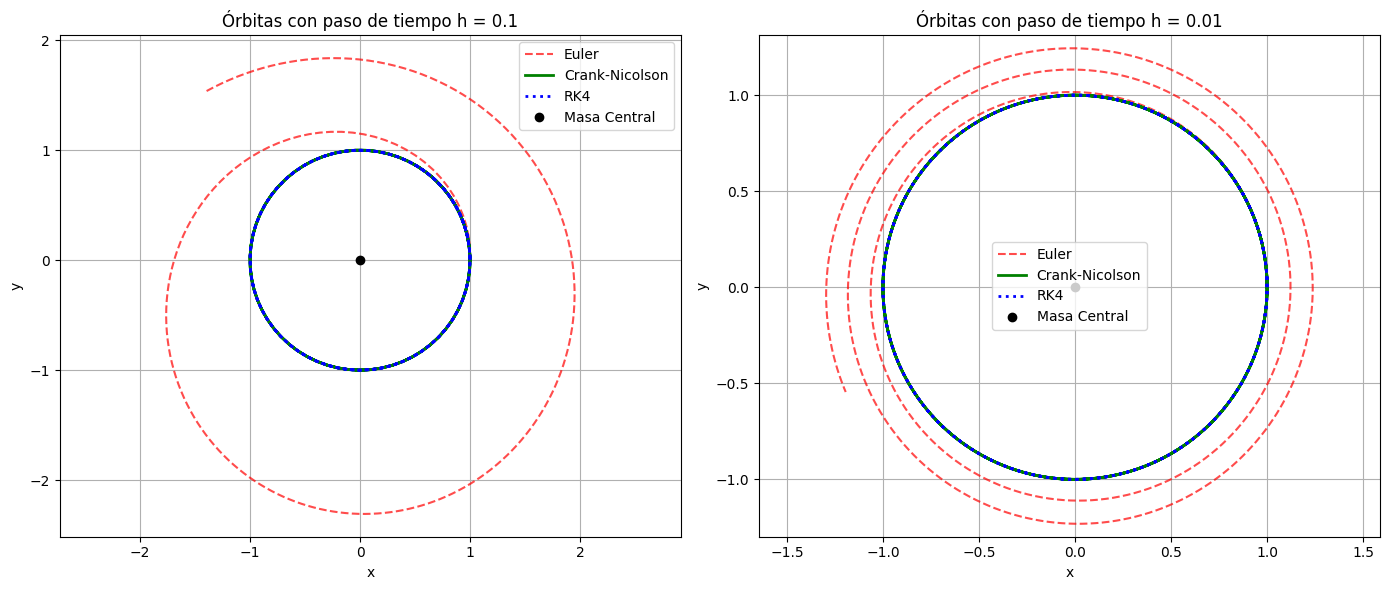

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# 1. Función de derivadas para la dinámica orbital (Problema de 2 cuerpos)
def orbital_dynamics(U):
    x, y, vx, vy = U
    r = np.sqrt(x**2 + y**2)
    # Aceleración gravitacional (mu = 1)
    ax = -x / r**3
    ay = -y / r**3 
    return np.array([vx, vy, ax, ay])

# 2. Métodos de Integración Independientes
def euler_orbit(U0, t_max, h):
    times = np.arange(0, t_max, h)
    U = np.zeros((len(times), 4))
    U[0] = U0
    for i in range(len(times) - 1):
        U[i+1] = U[i] + h * orbital_dynamics(U[i])
    return U[:, 0], U[:, 1]

def crank_nicolson_orbit(U0, t_max, h):
    times = np.arange(0, t_max, h)
    U = np.zeros((len(times), 4))
    U[0] = U0
    
    for i in range(len(times) - 1):
        def residual(U_next):
            return U_next - U[i] - (h / 2.0) * (orbital_dynamics(U[i]) + orbital_dynamics(U_next))
        
        # Predicción inicial con Euler para ayudar a fsolve
        U_guess = U[i] + h * orbital_dynamics(U[i])
        U[i+1] = fsolve(residual, U_guess)
        
    return U[:, 0], U[:, 1]

def rk4_orbit(U0, t_max, h):
    times = np.arange(0, t_max, h)
    U = np.zeros((len(times), 4))
    U[0] = U0
    for i in range(len(times) - 1):
        k1 = orbital_dynamics(U[i])
        k2 = orbital_dynamics(U[i] + 0.5 * h * k1)
        k3 = orbital_dynamics(U[i] + 0.5 * h * k2)
        k4 = orbital_dynamics(U[i] + h * k3)
        U[i+1] = U[i] + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return U[:, 0], U[:, 1]

# 3. Configuración y ejecución de la simulación
# Condición inicial para órbita circular de radio 1
U0_circular = np.array([1.0, 0.0, 0.0, 1.0])
t_simulacion = 20.0  # Tiempo suficiente para varias revoluciones
pasos_de_tiempo = [0.1, 0.01]  # Variación del paso de tiempo (h)

# 4. Graficación
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

for idx, h in enumerate(pasos_de_tiempo):
    # Ejecutar los tres métodos
    x_e, y_e = euler_orbit(U0_circular, t_simulacion, h)
    x_cn, y_cn = crank_nicolson_orbit(U0_circular, t_simulacion, h)
    x_rk, y_rk = rk4_orbit(U0_circular, t_simulacion, h)
    
    # Dibujar resultados
    axs[idx].plot(x_e, y_e, 'r--', label='Euler', alpha=0.7)
    axs[idx].plot(x_cn, y_cn, 'g-', label='Crank-Nicolson', linewidth=2)
    axs[idx].plot(x_rk, y_rk, 'b:', label='RK4', linewidth=2)
    axs[idx].plot(0, 0, 'ko', label='Masa Central')
    
    axs[idx].set_title(f'Órbitas con paso de tiempo h = {h}')
    axs[idx].set_xlabel('x')
    axs[idx].set_ylabel('y')
    axs[idx].axis('equal')
    axs[idx].grid(True)
    axs[idx].legend()

plt.tight_layout()
plt.show()